# 1. Instalasi Library
Kita memerlukan `rank_bm25` untuk menghitung fitur BM25, serta `optuna` untuk Hyperparameter Optimization (HPO). Tensorflow/Keras akan digunakan untuk RNN.

In [1]:
pip install rank_bm25 optuna scikit-learn nltk tensorflow pandas numpy seaborn pydot graphviz

Note: you may need to restart the kernel to use updated packages.


# 2. Import Libraries
Import seluruh library yang dibutuhkan untuk EDA, Preprocessing, Feature Engineering, dan Pemodelan.

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import random
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Concatenate, Dropout, GlobalMaxPooling1D, Attention, Multiply, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import optuna

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

nltk.download('stopwords', quiet=True)
try:
    stop_words = set(stopwords.words('indonesian'))
except:
    stop_words = set(['yang', 'di', 'dan', 'itu', 'dengan', 'untuk', 'tidak', 'ini', 'dari', 'dalam', 'akan', 'pada', 'juga', 'saya', 'ke', 'karena', 'tersebut', 'bisa', 'ada', 'mereka', 'lebih', 'sudah', 'atau', 'saat', 'oleh', 'menjadi'])

### Visualisasi: Diagram Alur Pipeline

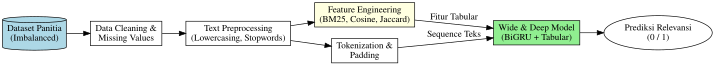

In [3]:
from graphviz import Digraph
from IPython.display import display

dot = Digraph(comment='Pipeline Sistem', format='png')
dot.attr(rankdir='LR', size='10,5')

dot.node('A', 'Dataset Panitia\n(Imbalanced)', shape='cylinder', style='filled', fillcolor='lightblue')
dot.node('B', 'Data Cleaning &\nMissing Values', shape='box')
dot.node('C', 'Text Preprocessing\n(Lowercasing, Stopwords)', shape='box')
dot.node('D', 'Feature Engineering\n(BM25, Cosine, Jaccard)', shape='box', style='filled', fillcolor='lightyellow')
dot.node('E', 'Tokenization &\nPadding', shape='box')
dot.node('F', 'Wide & Deep Model\n(BiGRU + Tabular)', shape='box', style='filled', fillcolor='lightgreen')
dot.node('G', 'Prediksi Relevansi\n(0 / 1)', shape='ellipse')

dot.edges(['AB', 'BC', 'CD', 'CE'])
dot.edge('D', 'F', label=' Fitur Tabular')
dot.edge('E', 'F', label=' Sequence Teks')
dot.edge('F', 'G')

dot.render('3_pipeline_flowchart', view=True)
display(dot)

# 3. Cell 3: Load Data & Karantina Set Validasi (Perbaikan Typo)
Sesuai dengan alur EDA yang Anda berikan, kita membersihkan duplikat dan *missing values*, serta melihat distribusi kelas.
File diasumsikan berada di folder `data/`.

In [4]:
print("Memuat Data Asli...")
train_internal = pd.read_csv('/kaggle/input/competitions/penyisihan-ifest-2026-dac/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/penyisihan-ifest-2026-dac/test.csv')

train_internal = train_internal.drop_duplicates(subset=["title", "content"], keep="first").reset_index(drop=True)
train_internal = train_internal.dropna(subset=["title", "content", "label"]).reset_index(drop=True)

test_df["title"] = test_df["title"].fillna("").astype(str)
test_df["content"] = test_df["content"].fillna("").astype(str)

print("Memisahkan Validation Set (100% Murni Internal)...")
idx_internal = np.arange(len(train_internal))
train_idx, val_idx = train_test_split(idx_internal, test_size=0.2, random_state=SEED, stratify=train_internal['label'])

df_train_pure = train_internal.iloc[train_idx].copy().reset_index(drop=True)
df_val_final = train_internal.iloc[val_idx].copy().reset_index(drop=True)

Memuat Data Asli...


Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '3_pipeline_flowchart.png'


Memisahkan Validation Set (100% Murni Internal)...


### Visualisasi EDA

/tmp/ipykernel_58/1921120491.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train_pure, x='label', palette='viridis')


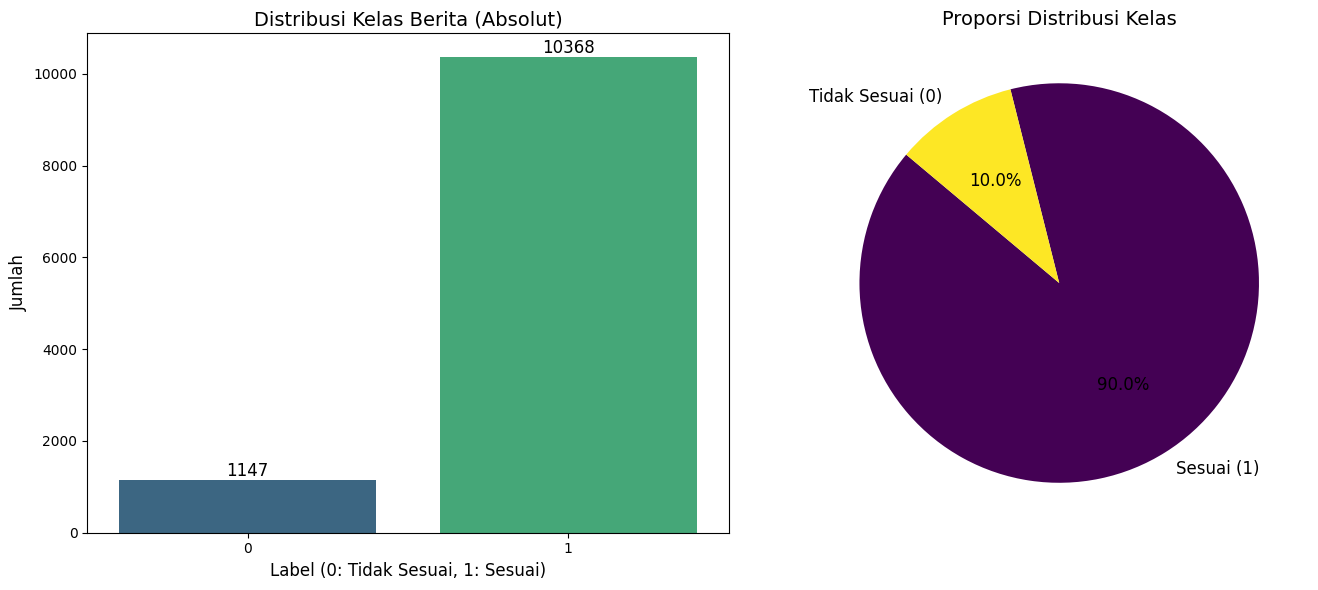

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
ax = sns.countplot(data=df_train_pure, x='label', palette='viridis')
plt.title('Distribusi Kelas Berita (Absolut)', fontsize=14)
plt.xlabel('Label (0: Tidak Sesuai, 1: Sesuai)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.subplot(1, 2, 2)
labels = ['Sesuai (1)', 'Tidak Sesuai (0)']
sizes = df_train_pure['label'].value_counts().values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#440154', '#fde725'], textprops={'fontsize': 12})
plt.title('Proporsi Distribusi Kelas', fontsize=14)

plt.tight_layout()
plt.savefig('1_distribusi_kelas.png', dpi=300)
plt.show()

# 4. Labeling Data Eksternal (Handling Imbalance)
Distribusi label 0 sangat sedikit (9.96%). Untuk meningkatkan performa model (khususnya metrik Macro F1), kita akan menggunakan `news_data.csv`.
Strategi: 
1. Ambil baris dari `news_data.csv` yang memiliki judul dan isi (ini akan jadi kelas 1 / Sesuai).
2. Lakukan *shuffle* / acak isi beritanya agar tidak cocok dengan judulnya (ini akan jadi kelas 0 / Tidak Sesuai).
3. Gabungkan dengan data train utama agar kelas menjadi lebih seimbang.

In [6]:
print("Menggunakan Data Internal Murni (Fokus pada pola Clickbait/Kontradiksi asli)...")
df_train_final = df_train_pure.copy()

print("\nDistribusi Kelas Training Set Asli:")
print(df_train_final['label'].value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi Kelas Validation Set (Karantina):")
print(df_val_final['label'].value_counts(normalize=True).mul(100).round(2))

Menggunakan Data Internal Murni (Fokus pada pola Clickbait/Kontradiksi asli)...

Distribusi Kelas Training Set Asli:
label
1    90.04
0     9.96
Name: proportion, dtype: float64

Distribusi Kelas Validation Set (Karantina):
label
1    90.03
0     9.97
Name: proportion, dtype: float64


# 5. Text Preprocessing
Melakukan *lowercasing*, membersihkan tanda baca, dan menghapus *stopwords* (kata hubung) agar model dan ekstraksi fitur (TF-IDF & BM25) lebih fokus pada kata-kata penting.

In [7]:
def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(f'[{re.escape(string.punctuation)}0-9]', ' ', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return " ".join(tokens)

print("Memulai Preprocessing Teks...")
df_train_final['clean_title'] = df_train_final['title'].apply(preprocess_text)
df_train_final['clean_content'] = df_train_final['content'].apply(preprocess_text)

df_val_final['clean_title'] = df_val_final['title'].apply(preprocess_text)
df_val_final['clean_content'] = df_val_final['content'].apply(preprocess_text)

test_df['clean_title'] = test_df['title'].apply(preprocess_text)
test_df['clean_content'] = test_df['content'].apply(preprocess_text)
print("Preprocessing Selesai.")

Memulai Preprocessing Teks...
Preprocessing Selesai.


### Visualisasi EDA: Distribusi Panjang Teks

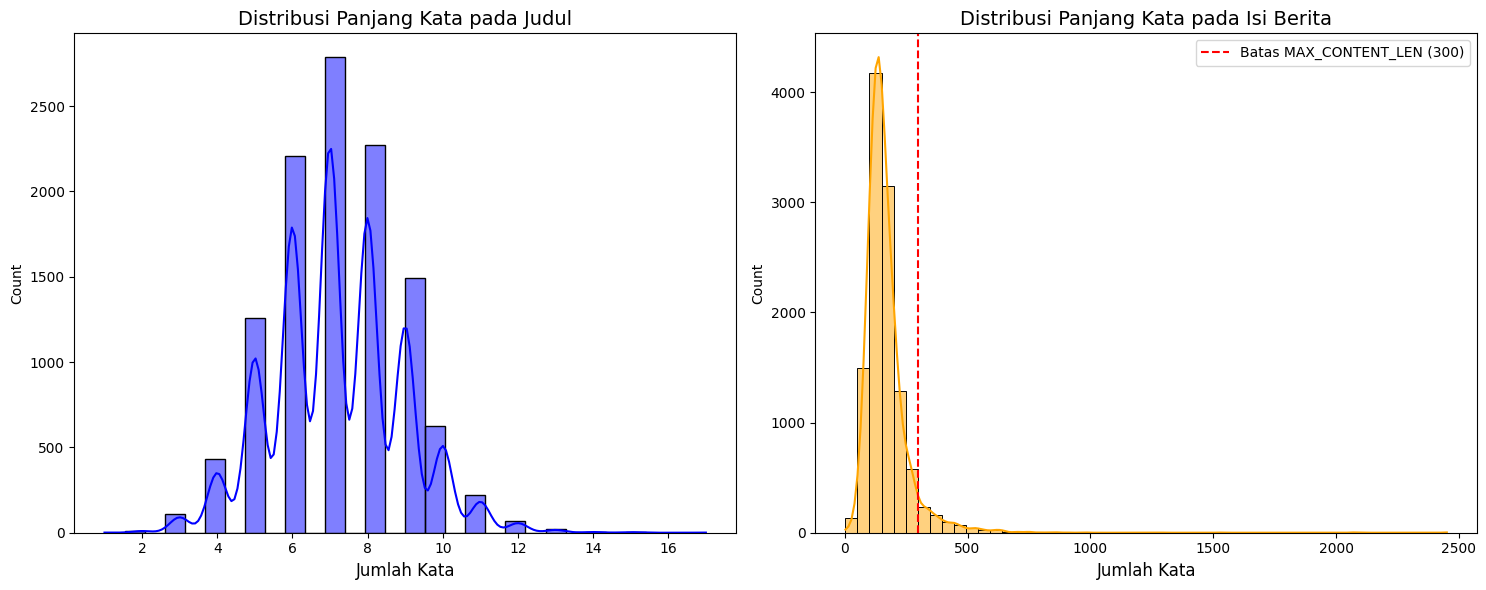

In [8]:
title_lens = df_train_final['clean_title'].apply(lambda x: len(str(x).split()))
content_lens = df_train_final['clean_content'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(title_lens, bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribusi Panjang Kata pada Judul', fontsize=14)
axes[0].set_xlabel('Jumlah Kata', fontsize=12)

sns.histplot(content_lens, bins=50, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Distribusi Panjang Kata pada Isi Berita', fontsize=14)
axes[1].set_xlabel('Jumlah Kata', fontsize=12)
axes[1].axvline(x=300, color='red', linestyle='--', label='Batas MAX_CONTENT_LEN (300)')
axes[1].legend()

plt.tight_layout()
plt.savefig('2_distribusi_panjang_kata.png', dpi=300)
plt.show()

# 6. Feature Engineering (Handcrafted Features)
Di sini kita mengekstrak kedekatan teks menggunakan **BM25**, **TF-IDF Cosine Similarity**, dan **Jaccard Similarity**.
Ini akan sangat membantu model dalam mendeteksi relevansi (tidak hanya bergantung pada Word Embedding internal RNN).

In [9]:
def calculate_jaccard(str1, str2):
    a = set(str1.split())
    b = set(str2.split())
    if not a or not b: return 0.0
    return len(a.intersection(b)) / len(a.union(b))

def get_single_bm25_score(bm25_obj, query_tokens, doc_tokens):
    """Menghitung skor BM25 sepasang query dan dokumen menggunakan bobot IDF global."""
    if len(doc_tokens) == 0 or len(query_tokens) == 0: return 0.0
    
    term_freqs = {word: doc_tokens.count(word) for word in set(doc_tokens)}
    score = 0.0
    for q in query_tokens:
        if q in bm25_obj.idf:
            tf = term_freqs.get(q, 0)
            num = tf * (bm25_obj.k1 + 1)
            den = tf + bm25_obj.k1 * (1 - bm25_obj.b + bm25_obj.b * len(doc_tokens) / bm25_obj.avgdl)
            score += bm25_obj.idf[q] * (num / den)
    return score

print("Fitting Global TF-IDF & BM25 pada Training Set...")
# Fit TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(pd.concat([df_train_final['clean_title'], df_train_final['clean_content']]))

train_corpus_tokens = [doc.split() for doc in df_train_final['clean_content']]
global_bm25 = BM25Okapi(train_corpus_tokens)

CLICKBAIT_WORDS = [
    'ternyata', 'heboh', 'gempar', 'viral', 'terungkap', 'rahasia',
    'dahsyat', 'mengejutkan', 'waduh', 'astaga', 'bikin kaget', 'kaget',
    'innalillahi', 'gokil', 'parah', 'bukan main', 'nyesel', 'wajib tahu',
    'jangan sampai', 'baru tahu', 'ngeri', 'syok', 'histeris', 'sadis'
]

def extract_numbers(text):
    return set(re.findall(r'\d+', str(text)))

def calculate_number_match(title_raw, content_raw):
    """Bandingkan angka di judul vs isi (pakai teks ASLI, sebelum digit dihapus preprocessing)."""
    title_nums = extract_numbers(title_raw)
    content_nums = extract_numbers(content_raw)
    if not title_nums:
        return 1.0  # tidak ada angka di judul -> tidak relevan, dianggap netral
    return len(title_nums.intersection(content_nums)) / len(title_nums)

def calculate_lead_overlap(clean_title, clean_content, n_words=40):
    """Overlap kata judul dengan ~40 kata pertama isi (proxy lead paragraph)."""
    lead_words = set(clean_content.split()[:n_words])
    title_words = set(clean_title.split())
    if not title_words or not lead_words:
        return 0.0
    return len(title_words.intersection(lead_words)) / len(title_words)

def calculate_clickbait_score(title_raw):
    title_lower = str(title_raw).lower()
    score = sum(1 for w in CLICKBAIT_WORDS if w in title_lower)
    score += str(title_raw).count('!') + str(title_raw).count('?')
    return score

def calculate_caps_ratio(title_raw):
    words = str(title_raw).split()
    if not words:
        return 0.0
    caps_words = [w for w in words if w.isupper() and len(w) > 1]
    return len(caps_words) / len(words)

def extract_features(df):
    df = df.copy()
    
    # 1. Jaccard Similarity
    df['jaccard_sim'] = df.apply(lambda x: calculate_jaccard(x['clean_title'], x['clean_content']), axis=1)
    
    # 2. TF-IDF Cosine Similarity
    title_tfidf = tfidf.transform(df['clean_title'])
    content_tfidf = tfidf.transform(df['clean_content'])
    df['tfidf_cosine_sim'] = np.array([cosine_similarity(t, c)[0][0] for t, c in zip(title_tfidf, content_tfidf)])
    
    # 3. BM25 Score (Statistically Valid)
    bm25_scores = []
    for title, content in zip(df['clean_title'], df['clean_content']):
        score = get_single_bm25_score(global_bm25, title.split(), content.split())
        bm25_scores.append(score)
    df['bm25_score'] = bm25_scores
    
    # 4. Length Difference
    df['len_diff'] = df['clean_content'].apply(lambda x: len(x.split())) - df['clean_title'].apply(lambda x: len(x.split()))

        # 5. Number Matching (pakai kolom title/content ASLI, sebelum digit dihapus)
    df['num_match_ratio'] = df.apply(lambda x: calculate_number_match(x['title'], x['content']), axis=1)

    # 6. Lead Paragraph Overlap
    df['lead_overlap'] = df.apply(lambda x: calculate_lead_overlap(x['clean_title'], x['clean_content']), axis=1)

    # 7. Clickbait Trigger Score
    df['clickbait_score'] = df['title'].apply(calculate_clickbait_score)

    # 8. Capitalization Ratio pada Judul
    df['caps_ratio'] = df['title'].apply(calculate_caps_ratio)
    
    return df

print("Mengekstrak Fitur Numerik...")
df_train_final = extract_features(df_train_final)
df_val_final = extract_features(df_val_final)
test_df = extract_features(test_df)
print("Feature Engineering Selesai untuk seluruh data.")

Fitting Global TF-IDF & BM25 pada Training Set...
Mengekstrak Fitur Numerik...
Feature Engineering Selesai untuk seluruh data.


### Visualisasi Analisis: Distribusi Fitur Tabular per Label

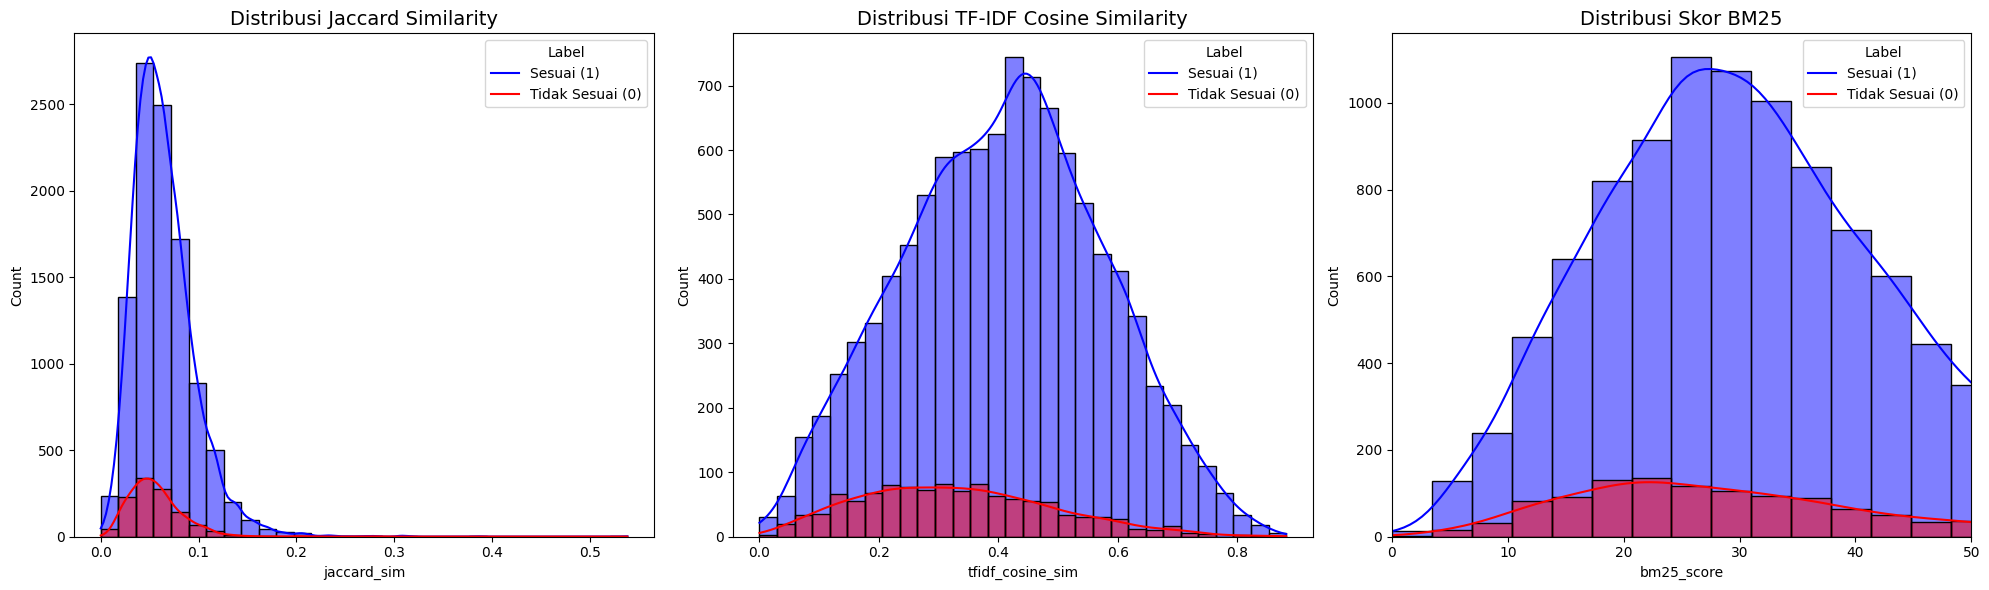

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(data=df_train_final, x='jaccard_sim', hue='label', bins=30, kde=True, ax=axes[0], palette=['red', 'blue'])
axes[0].set_title('Distribusi Jaccard Similarity', fontsize=14)

sns.histplot(data=df_train_final, x='tfidf_cosine_sim', hue='label', bins=30, kde=True, ax=axes[1], palette=['red', 'blue'])
axes[1].set_title('Distribusi TF-IDF Cosine Similarity', fontsize=14)

sns.histplot(data=df_train_final, x='bm25_score', hue='label', bins=30, kde=True, ax=axes[2], palette=['red', 'blue'])
axes[2].set_title('Distribusi Skor BM25', fontsize=14)
axes[2].set_xlim(0, 50) 

for ax in axes:
    ax.legend(title='Label', labels=['Sesuai (1)', 'Tidak Sesuai (0)'])

plt.tight_layout()
plt.savefig('8_distribusi_fitur.png', dpi=300)
plt.show()

# 7. Persiapan Data untuk Jaringan Syaraf Tiruan (RNN)
Kita menggunakan arsitektur **Wide & Deep Learning**.
*   **Deep Component (RNN):** Menerima urutan *token/integer* teks, diproses lewat Keras `Embedding` layer yang dilatih dari awal, dan dipahami menggunakan **BiGRU** (Bidirectional Gated Recurrent Unit). *BiGRU dipilih karena komputasinya lebih ringan dari LSTM namun seringkali memberikan hasil yang setara atau lebih baik pada teks.*
*   **Wide Component (Dense):** Menerima fitur numerik yang baru saja kita ekstrak (BM25, Cosine, Jaccard).

In [11]:
from sklearn.preprocessing import StandardScaler

MAX_VOCAB = 25000
MAX_TITLE_LEN = 30
MAX_CONTENT_LEN = 300

print("Tokenisasi teks & Normalisasi Tabular...")
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(pd.concat([df_train_final['clean_title'], df_train_final['clean_content']]))

# Ekstrak Teks
train_title_seq = pad_sequences(tokenizer.texts_to_sequences(df_train_final['clean_title']), maxlen=MAX_TITLE_LEN, padding='post')
train_content_seq = pad_sequences(tokenizer.texts_to_sequences(df_train_final['clean_content']), maxlen=MAX_CONTENT_LEN, padding='post')
val_title_seq = pad_sequences(tokenizer.texts_to_sequences(df_val_final['clean_title']), maxlen=MAX_TITLE_LEN, padding='post')
val_content_seq = pad_sequences(tokenizer.texts_to_sequences(df_val_final['clean_content']), maxlen=MAX_CONTENT_LEN, padding='post')
test_title_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_title']), maxlen=MAX_TITLE_LEN, padding='post')
test_content_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_content']), maxlen=MAX_CONTENT_LEN, padding='post')

TABULAR_COLS = ['jaccard_sim', 'tfidf_cosine_sim', 'bm25_score', 'len_diff',
                 'num_match_ratio', 'lead_overlap', 'clickbait_score', 'caps_ratio']

# Ekstrak & Skalakan Fitur Tabular
scaler = StandardScaler()
train_tabular = scaler.fit_transform(df_train_final[TABULAR_COLS].values)
val_tabular   = scaler.transform(df_val_final[TABULAR_COLS].values)
test_tabular  = scaler.transform(test_df[TABULAR_COLS].values)

X_train = {'title_input': train_title_seq, 'content_input': train_content_seq, 'tabular_input': train_tabular}
y_train = df_train_final['label'].values

X_val = {'title_input': val_title_seq, 'content_input': val_content_seq, 'tabular_input': val_tabular}
y_val = df_val_final['label'].values

X_test = {'title_input': test_title_seq, 'content_input': test_content_seq, 'tabular_input': test_tabular}
print("Persiapan Data Hibrida Selesai.")

Tokenisasi teks & Normalisasi Tabular...
Persiapan Data Hibrida Selesai.


# 8. Model Architecture (BiGRU + Handcrafted Features)
Menggabungkan urutan teks dengan metrik kedekatan statistik (BM25, TF-IDF).

In [12]:
class MaskedGlobalMaxPool1D(tf.keras.layers.Layer):
    def call(self, inputs, mask=None):
        if mask is not None:
            mask = tf.cast(mask, inputs.dtype)
            mask = tf.expand_dims(mask, axis=-1)
            inputs = inputs * mask + (1.0 - mask) * -1e9
        return tf.reduce_max(inputs, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

def build_model(gru_units=64, dropout_rate=0.3, learning_rate=1e-3):
    title_in = Input(shape=(MAX_TITLE_LEN,), name='title_input')
    content_in = Input(shape=(MAX_CONTENT_LEN,), name='content_input')
    tabular_in = Input(shape=(len(TABULAR_COLS),), name='tabular_input')
    embed_layer = Embedding(input_dim=MAX_VOCAB, output_dim=64, mask_zero=True, name='word_embedding')

    title_embed = embed_layer(title_in)
    content_embed = embed_layer(content_in)

    shared_gru = Bidirectional(GRU(gru_units, return_sequences=True))
    title_seq = shared_gru(title_embed)
    content_seq = shared_gru(content_embed)

    title_pooled = MaskedGlobalMaxPool1D()(title_seq)
    content_pooled = MaskedGlobalMaxPool1D()(content_seq)

    attn_content = Attention(use_scale=True, name='title_to_content_attention')([title_seq, content_seq])
    attended_content_pooled = MaskedGlobalMaxPool1D()(attn_content)

    abs_diff = Lambda(lambda x: tf.abs(x[0] - x[1]), name='abs_diff')([title_pooled, content_pooled])
    elem_mult = Multiply(name='elem_mult')([title_pooled, content_pooled])

    merged = Concatenate()([
        title_pooled, content_pooled, attended_content_pooled,
        abs_diff, elem_mult, tabular_in
    ])

    dense_1 = Dense(128, activation='relu')(merged)
    dense_1 = Dropout(dropout_rate)(dense_1)
    dense_2 = Dense(64, activation='relu')(dense_1)

    output = Dense(1, activation='sigmoid', name='output')(dense_2)

    model = Model(inputs=[title_in, content_in, tabular_in], outputs=output)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# 9. Hyperparameter Optimization (HPO) menggunakan Optuna
Mencari parameter GRU Units, Dropout, dan Learning Rate terbaik.

In [13]:
bobot_kelas = {0: 3.0, 1: 1.0}

DO_HPO = True 

def objective(trial):
    gru_units = trial.suggest_categorical('gru_units', [32, 64, 128])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)
    
    model = build_model(gru_units=gru_units, dropout_rate=dropout_rate, learning_rate=learning_rate)
    early_stop_hpo = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
    
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=3, 
        batch_size=64,
        verbose=0,
        class_weight=bobot_kelas,
        callbacks=[early_stop_hpo]
    )
    
    y_pred_prob = model.predict(X_val, verbose=0)
    best_trial_f1 = 0.0
    for th in np.arange(0.1, 0.9, 0.05):
        y_pred = (y_pred_prob >= th).astype(int)
        f1 = f1_score(y_val, y_pred, average='macro')
        if f1 > best_trial_f1:
            best_trial_f1 = f1

    return best_trial_f1

if DO_HPO:
    print("Memulai Hyperparameter Optimization...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=4) 
    
    print("Parameter Terbaik: ", study.best_params)
    best_model = build_model(**study.best_params)
else:
    best_model = build_model(gru_units=64, dropout_rate=0.3, learning_rate=1e-3)

print("\nMelatih Model Final...")
early_stop_final = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    class_weight=bobot_kelas,
    callbacks=[early_stop_final]
)

[I 2026-09-11 08:56:37,940] A new study created in memory with name: no-name-df72f073-3752-4ba8-ae80-a6da9f9d746f


Memulai Hyperparameter Optimization...


[I 2026-09-11 09:02:26,101] Trial 0 finished with value: 0.6101732714840538 and parameters: {'gru_units': 128, 'dropout_rate': 0.3764730987303879, 'learning_rate': 0.000835863467530761}. Best is trial 0 with value: 0.6101732714840538.
[I 2026-09-11 09:10:54,845] Trial 1 finished with value: 0.5935964325560629 and parameters: {'gru_units': 128, 'dropout_rate': 0.4439090284823806, 'learning_rate': 0.00041018528924231627}. Best is trial 0 with value: 0.6101732714840538.
[I 2026-09-11 09:13:57,314] Trial 2 finished with value: 0.5940998783954372 and parameters: {'gru_units': 32, 'dropout_rate': 0.4355438551245163, 'learning_rate': 0.0006031231179795861}. Best is trial 0 with value: 0.6101732714840538.
[I 2026-09-11 09:16:02,528] Trial 3 finished with value: 0.5984508100437245 and parameters: {'gru_units': 32, 'dropout_rate': 0.2541831412959736, 'learning_rate': 0.001098505318538426}. Best is trial 0 with value: 0.6101732714840538.


Parameter Terbaik:  {'gru_units': 128, 'dropout_rate': 0.3764730987303879, 'learning_rate': 0.000835863467530761}

Melatih Model Final...
Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 161s 842ms/step - accuracy: 0.8919 - loss: 0.6442 - val_accuracy: 0.8899 - val_loss: 0.3668
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 153s 847ms/step - accuracy: 0.8836 - loss: 0.5221 - val_accuracy: 0.8329 - val_loss: 0.3929
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 153s 849ms/step - accuracy: 0.9209 - loss: 0.2882 - val_accuracy: 0.8010 - val_loss: 0.5922


# 10. Evaluasi Akhir (Macro F1-Score)

In [14]:
import os

print("=== 1. EVALUASI & MENCARI THRESHOLD TERBAIK ===")
val_preds_probs = best_model.predict(X_val)

best_th = 0.50
best_f1 = 0.0

for th in np.arange(0.1, 0.9, 0.05):
    val_preds = (val_preds_probs >= th).astype(int)
    f1 = f1_score(y_val, val_preds, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"Threshold optimal ditemukan: {best_th:.2f} dengan Val Macro F1: {best_f1:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, (val_preds_probs >= best_th).astype(int), target_names=['Tidak Sesuai (0)', 'Sesuai (1)']))

print("\n=== 2. MEMBUAT PREDIKSI DATA TEST ===")
test_preds_probs = best_model.predict(X_test)
test_labels = (test_preds_probs >= best_th).astype(int)

try:
    sample_sub = pd.read_csv('/kaggle/input/competitions/penyisihan-ifest-2026-dac/sample_submission.csv')
except FileNotFoundError:
    sample_sub = pd.DataFrame({'id': test_df['id']})

sample_sub['label'] = test_labels
sample_sub.to_csv('submission.csv', index=False)

print(f'\nSubmission saved! Distribusi prediksi kelas:')
print(sample_sub['label'].value_counts())
print(f"\nFile submission.csv berhasil dibuat di:\n{os.path.abspath('submission.csv')}")

=== 1. EVALUASI & MENCARI THRESHOLD TERBAIK ===
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step
Threshold optimal ditemukan: 0.55 dengan Val Macro F1: 0.6037

Classification Report (Validation):
                  precision    recall  f1-score   support

Tidak Sesuai (0)       0.30      0.26      0.28       287
      Sesuai (1)       0.92      0.93      0.93      2592

        accuracy                           0.87      2879
       macro avg       0.61      0.60      0.60      2879
    weighted avg       0.86      0.87      0.86      2879


=== 2. MEMBUAT PREDIKSI DATA TEST ===
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step

Submission saved! Distribusi prediksi kelas:
label
1    3291
0     312
Name: count, dtype: int64

File submission.csv berhasil dibuat di:
/kaggle/working/submission.csv


### Visualisasi Evaluasi: Confusion Matrix

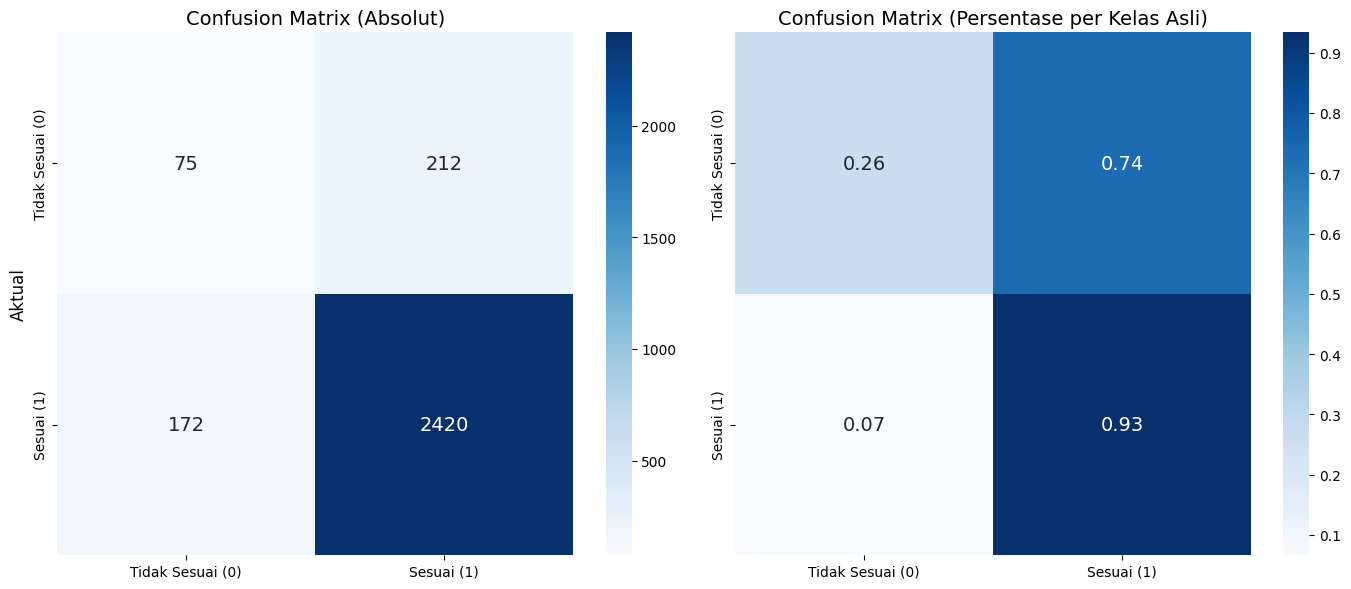

In [15]:
from sklearn.metrics import confusion_matrix

val_preds = (val_preds_probs >= best_th).astype(int)
cm_abs = confusion_matrix(y_val, val_preds)
cm_norm = confusion_matrix(y_val, val_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels = ['Tidak Sesuai (0)', 'Sesuai (1)']

sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix (Absolut)', fontsize=14)
axes[0].set_ylabel('Aktual', fontsize=12)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1], annot_kws={"size": 14})
axes[1].set_title('Confusion Matrix (Persentase per Kelas Asli)', fontsize=14)

plt.tight_layout()
plt.savefig('5_confusion_matrix.png', dpi=300)
plt.show()

In [16]:
# ============================================================
# TRAINING BASELINE MODELS (untuk komparasi & ensemble yang JUJUR)
# ============================================================
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

print("=== Melatih Baseline: Logistic Regression (TF-IDF) ===")
X_train_text = df_train_final['clean_title'] + ' ' + df_train_final['clean_content']
X_val_text   = df_val_final['clean_title'] + ' ' + df_val_final['clean_content']

X_train_tfidf = tfidf.transform(X_train_text)   # tfidf sudah di-fit di Section 6, HANYA pakai train
X_val_tfidf   = tfidf.transform(X_val_text)

logreg = LogisticRegression(class_weight={0: 3.0, 1: 1.0}, max_iter=1000, random_state=SEED)
logreg.fit(X_train_tfidf, y_train)
logreg_val_probs = logreg.predict_proba(X_val_tfidf)[:, 1]

print("=== Melatih Baseline: LightGBM (fitur tabular dense) ===")
lgbm = lgb.LGBMClassifier(
    class_weight={0: 3.0, 1: 1.0},
    n_estimators=300,
    random_state=SEED,
    verbose=-1
)
lgbm.fit(df_train_final[TABULAR_COLS], y_train)
lgbm_val_probs = lgbm.predict_proba(df_val_final[TABULAR_COLS])[:, 1]

def cari_threshold_terbaik(y_true, probs):
    best_th, best_f1 = 0.5, 0.0
    for th in np.arange(0.1, 0.9, 0.05):
        f1 = f1_score(y_true, (probs >= th).astype(int), average='macro')
        if f1 > best_f1:
            best_f1, best_th = f1, th
    return best_th, best_f1

# --- Skor tiap model (REAL, bukan hardcoded) ---
th_logreg, f1_logreg = cari_threshold_terbaik(y_val, logreg_val_probs)
th_lgbm, f1_lgbm     = cari_threshold_terbaik(y_val, lgbm_val_probs)

bigru_val_probs = val_preds_probs.flatten()  # dari Section 10, best_model.predict(X_val)
th_bigru, f1_bigru = cari_threshold_terbaik(y_val, bigru_val_probs)

# --- Ensemble sederhana: rata-rata probabilitas ketiga model ---
ensemble_val_probs = (logreg_val_probs + lgbm_val_probs + bigru_val_probs) / 3.0
th_ensemble, f1_ensemble = cari_threshold_terbaik(y_val, ensemble_val_probs)

print(f"\nLogReg      -> Macro F1: {f1_logreg:.4f} (th={th_logreg:.2f})")
print(f"LightGBM    -> Macro F1: {f1_lgbm:.4f} (th={th_lgbm:.2f})")
print(f"BiGRU       -> Macro F1: {f1_bigru:.4f} (th={th_bigru:.2f})")
print(f"Ensemble    -> Macro F1: {f1_ensemble:.4f} (th={th_ensemble:.2f})")

# --- Feature importance REAL dari LightGBM ---
feat_importance_df = pd.DataFrame({
    'feature': TABULAR_COLS,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance (LightGBM):")
print(feat_importance_df)

=== Melatih Baseline: Logistic Regression (TF-IDF) ===
=== Melatih Baseline: LightGBM (fitur tabular dense) ===

LogReg      -> Macro F1: 0.4950 (th=0.60)
LightGBM    -> Macro F1: 0.5761 (th=0.70)
BiGRU       -> Macro F1: 0.6037 (th=0.55)
Ensemble    -> Macro F1: 0.5813 (th=0.70)

Feature Importance (LightGBM):
            feature  importance
2        bm25_score        1953
0       jaccard_sim        1854
1  tfidf_cosine_sim        1789
3          len_diff        1689
5      lead_overlap         933
7        caps_ratio         679
4   num_match_ratio          92
6   clickbait_score          11


# 11. Analisis Lanjutan & Komparasi Model

/tmp/ipykernel_58/1257548452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance_df['importance'], y=feat_importance_df['feature'], palette='magma', ax=axes[0])
/tmp/ipykernel_58/1257548452.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nama_model, y=skor_f1, palette='coolwarm', ax=axes[1])


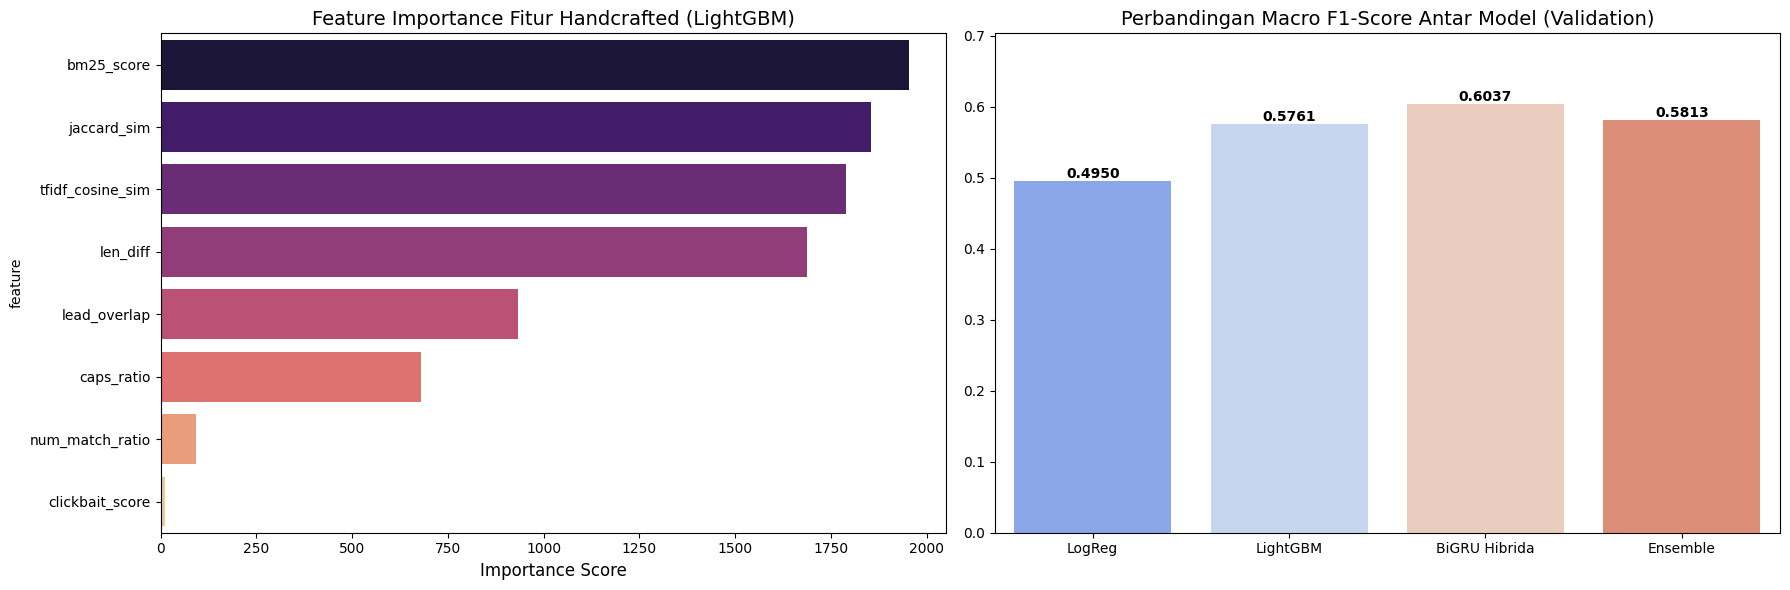

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Grafik 1: Feature Importance (REAL dari LightGBM) ---
sns.barplot(x=feat_importance_df['importance'], y=feat_importance_df['feature'], palette='magma', ax=axes[0])
axes[0].set_title('Feature Importance Fitur Handcrafted (LightGBM)', fontsize=14)
axes[0].set_xlabel('Importance Score', fontsize=12)

# --- Grafik 2: Komparasi Model (REAL) ---
nama_model = ['LogReg', 'LightGBM', 'BiGRU Hibrida', 'Ensemble']
skor_f1 = [f1_logreg, f1_lgbm, f1_bigru, f1_ensemble]

sns.barplot(x=nama_model, y=skor_f1, palette='coolwarm', ax=axes[1])
axes[1].set_title('Perbandingan Macro F1-Score Antar Model (Validation)', fontsize=14)
axes[1].set_ylim(0.0, max(skor_f1) + 0.1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('7_komparasi_dan_fitur.png', dpi=300)
plt.show()